# **Introduction**
### **Project Motivation & Background**
Heart disease, or cardiovascular disease (CVD), is a personal and global concern. CVD remains the leading cause of death worldwide, affecting millions and burdening healthcare systems. This project explores the use of machine learning models to predict the likelihood of heart disease using a real-world dataset. The aim is to enhance diagnostic accuracy by comparing different ML algorithms on key performance metrics.




### **Problem Overview**
The main issue this study focuses on it, Is overcomeing the challenge of predicting heart disease risk accurately with traditional methods. These methods sometimes lead to missed or incorrect diagnoses, which can have serious consequences. There is a need for better tools that can analyze complex and large datasets to detect hidden patterns indicative of heart disease. Machine learning (ML) offers a promising solution by improving the accuracy of risk prediction.

### **Outcomes:**

* Identify the patterns and characteristics in patient data that relate to heart health.
* Understand what risk factors contribute to the likelihood of developing heart disease.
* Compare different machine learning models to find the most accurate prediction model.

## **Model Development and Coding**

Importing Libraries

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

let's bring the dataset

In [ ]:
df_heart = pd.read_csv('Heart_Disease_Prediction.csv')

let's do some data engineering

In [ ]:
df = pd.read_csv('Heart_Disease_Prediction.csv')
df.head()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,Presence
1,80,0,3,115,564,0,2,160,0,1.6,2,0,7,Absence
2,55,1,2,124,261,0,0,141,0,0.3,1,0,7,Presence
3,65,1,4,128,263,0,0,105,1,0.2,2,1,7,Absence
4,45,0,2,120,269,0,2,121,1,0.2,1,1,3,Absence


In [ ]:
df.tail()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
265,52,1,3,172,199,1,0,162,0,0.5,1,0,7,Absence
266,44,1,2,120,263,0,0,173,0,0.0,1,0,7,Absence
267,56,0,2,140,294,0,2,153,0,1.3,2,0,3,Absence
268,57,1,4,140,192,0,0,148,0,0.4,2,0,6,Absence
269,67,1,4,160,286,0,2,108,1,1.5,2,3,3,Presence


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      270 non-null    int64  
 1   Sex                      270 non-null    int64  
 2   Chest pain type          270 non-null    int64  
 3   BP                       270 non-null    int64  
 4   Cholesterol              270 non-null    int64  
 5   FBS over 120             270 non-null    int64  
 6   EKG results              270 non-null    int64  
 7   Max HR                   270 non-null    int64  
 8   Exercise angina          270 non-null    int64  
 9   ST depression            270 non-null    float64
 10  Slope of ST              270 non-null    int64  
 11  Number of vessels fluro  270 non-null    int64  
 12  Thallium                 270 non-null    int64  
 13  Heart Disease            270 non-null    object 
dtypes: float64(1), int64(12), 

In [ ]:
df.describe()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
count,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.00000,270.000000,270.000000,270.000000
mean,54.077778,0.677778,3.174074,131.344444,249.659259,0.148148,1.022222,149.677778,0.329630,1.05000,1.585185,0.670370,4.696296
std,9.201052,0.468195,0.950090,17.861608,51.686237,0.355906,0.997891,23.165717,0.470952,1.14521,0.614390,0.943896,1.940659
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.00000,1.000000,0.000000,3.000000
25%,47.000000,0.000000,3.000000,120.000000,213.000000,0.000000,0.000000,133.000000,0.000000,0.00000,1.000000,0.000000,3.000000
50%,54.000000,1.000000,3.000000,130.000000,245.000000,0.000000,2.000000,153.500000,0.000000,0.80000,2.000000,0.000000,3.000000
75%,60.750000,1.000000,4.000000,140.000000,280.000000,0.000000,2.000000,166.000000,1.000000,1.60000,2.000000,1.000000,7.000000
max,80.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.20000,3.000000,3.000000,7.000000


In [ ]:
df.duplicated().sum()

0


***Takeways:***

Rows: 270 entries, 0 to 269  
Data columns = 14 columns    

No missing values,No duplications  so i can move directly to feature engineering and model building without needing clean data.

AS we see also types int64 and float64 types then we will scale them.

The Heart Disaese column is our target variable and we will need to be encoded as numerical values for machine learning eg. 0 or 1.

## **Data Exploration**

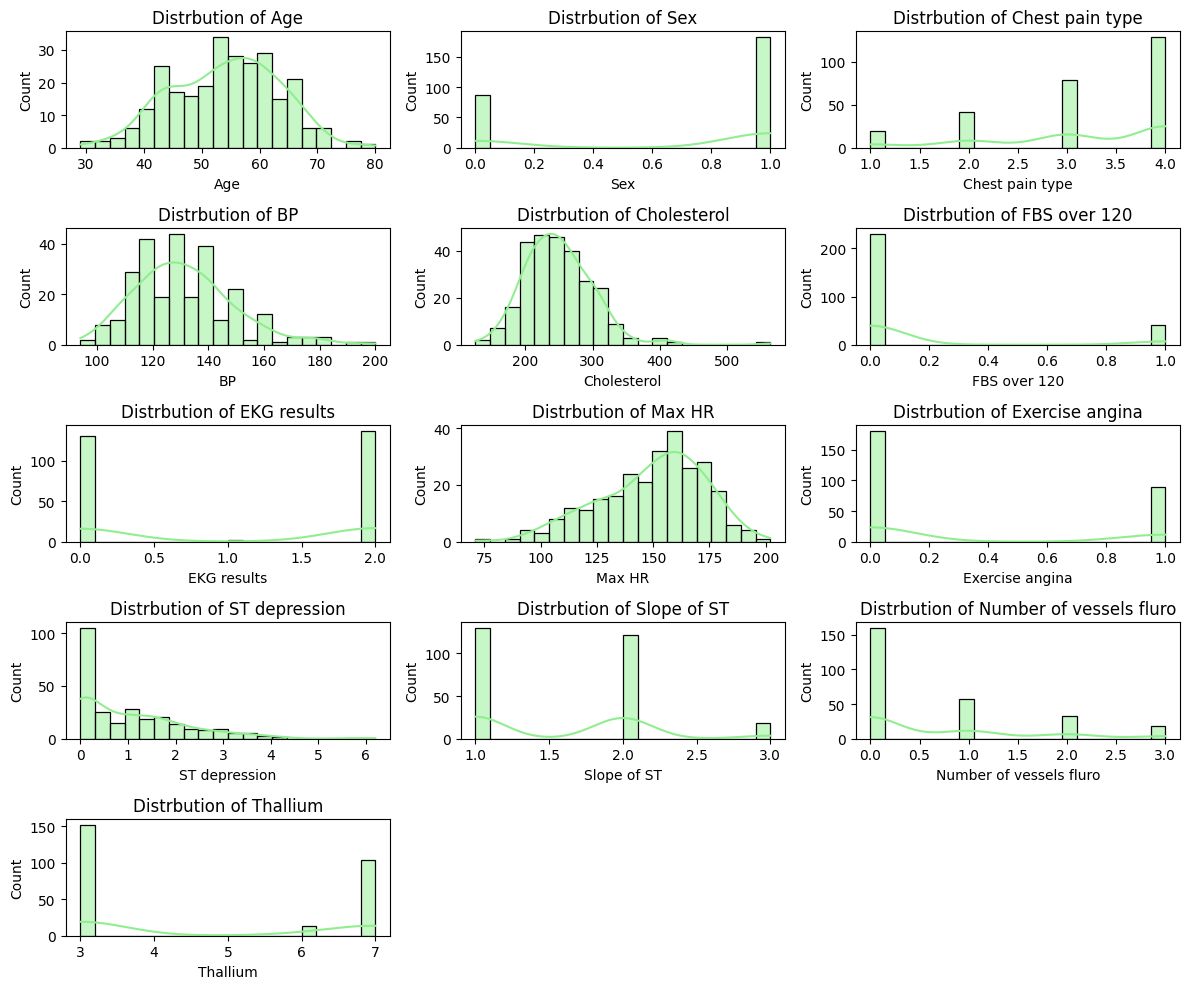

In [ ]:
numerical_colmns = df.select_dtypes(include=['float64', 'int64']).columns
plt.figure(figsize=(12, 10))
for i, col in enumerate(numerical_colmns, 1):
    plt.subplot(len(numerical_colmns) // 3 + 1, 3, i)
    sns.histplot(df[col], kde=True, bins=20, color='lightgreen')
    plt.title(f'Distrbution of {col}')
plt.tight_layout()
plt.show()

Observations:

Age: The age range is mostly between 45 to 70 years old.

Sex: There are more men than women in this dataset.

Chest Pain Type: The most common chest pain is the sever type (4).

Blood Pressure (BP):Blood pressure acts between 120 and 160 for most people.

Cholesterol: it's levels are generally seen around 200 to 300, another some people having higher levels.

FBS Over 120: Most of people don’t have high fasting blood sugar.

EKG Results: Most people has normal EKG results, otherside only a few having abnorml values.

Max Heart Rate (HR):Most people have thier heart rate between 100 and 170 .

Exercise Angina: Very few people experence chest pain during exercise.

ST Depression: Most people have very low ST depression values, with only a small number having higher values.

Slope of ST Segment: The majority have a medium slope (2), with fewer having low or high slopes.

Number of Vessels Fluoro: Most people have 0 or 1 vessel .

Thallium Test: The majority of the results are 3 , with other hand increese to high number having 7.














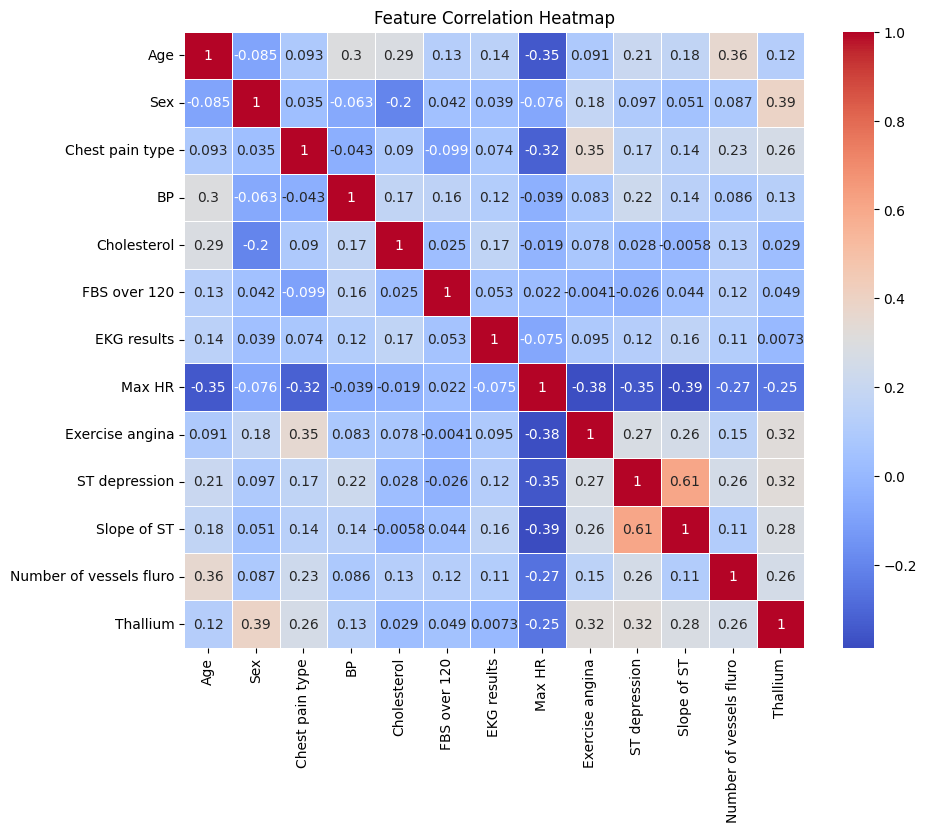

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.show()

This heatmap hilights key relationships between features, with Age, Max HR, and ST Depression emergng as crucial indicators of heart disease. Features like Sex, Chest Pain Type, and Number of Vessels show meaningful relations with other risk factors, providing valuable info for heart disease prediction. Handling these corelations effectively will help improve the model's acuracy.

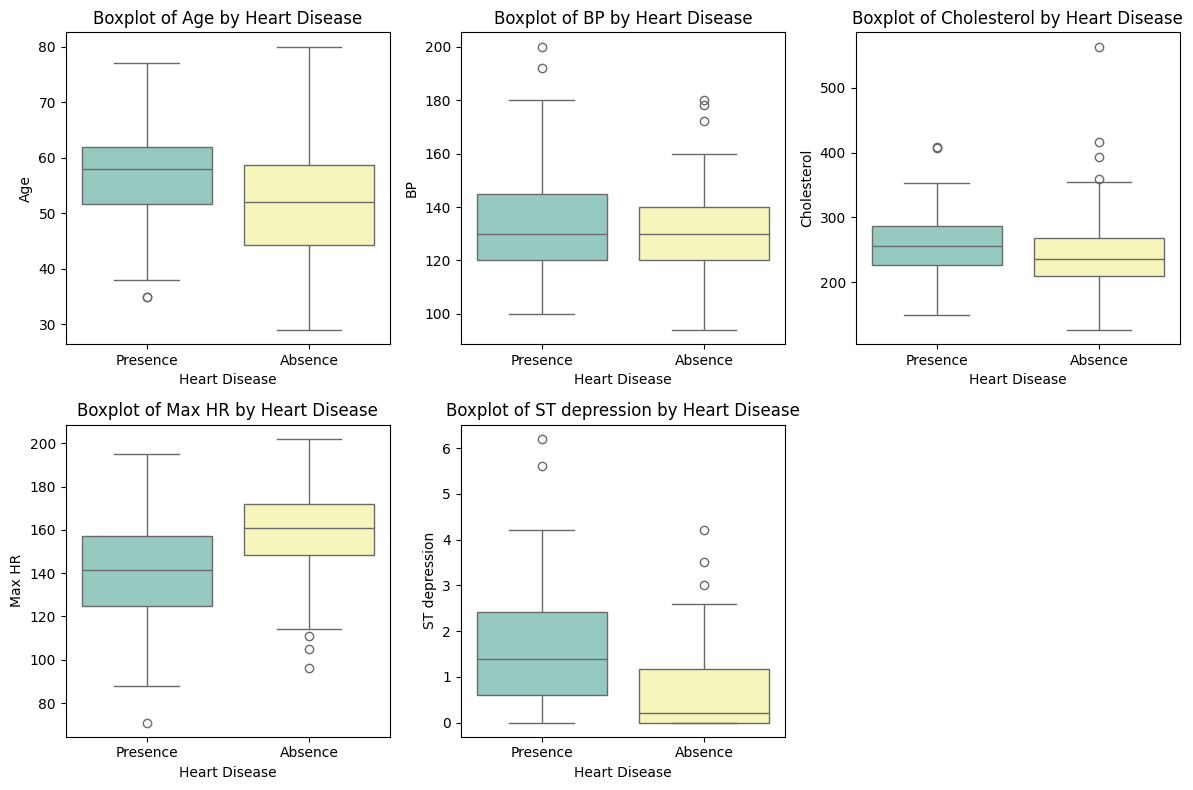

In [ ]:
numerical_featuers = ['Age', 'BP', 'Cholesterol', 'Max HR', 'ST depression']
plt.figure(figsize=(12, 8))
for i, featur in enumerate(numerical_featuers, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x='Heart Disease', y=featur, data=df, hue='Heart Disease', palette='Set3', dodge=False)
    plt.title(f'Boxplot of {featur} by Heart Disease')
plt.tight_layout()
plt.show()

The boxplots show that Age, max HR, and ST depresion are strong predictors for heart disease. Cholesterol and BP also contribute but may be less signifcant effect.

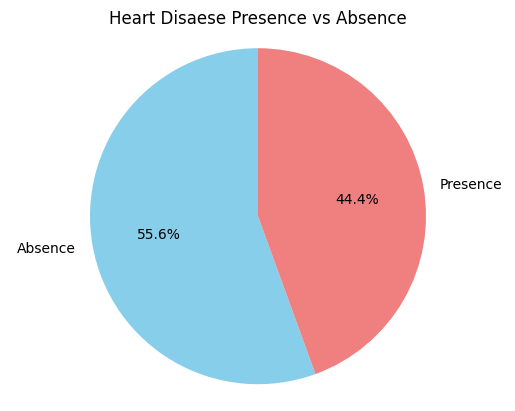

In [ ]:
heart_disease_counts = df['Heart Disease'].value_counts()
labels = ['Absence', 'Presence']
plt.pie(heart_disease_counts, labels=labels, autopct='%1.1f%%', colors=['skyblue', 'lightcoral'], startangle=90)
plt.title('Heart Disaese Presence vs Absence')
plt.axis('equal')
plt.show()

The pie chart shows that the dataset is not totaly balanced, with a slight majority of patients (55.6%) not having heart disease. onthe other hand , 44.4% of patients have been diagnosed with heart disease.

**Featuere Enginnering**

In [ ]:
label_encoder = LabelEncoder()
df_heart['Heart Disease'] = label_encoder.fit_transform(df_heart['Heart Disease'])

I transformed our target to num.

In [ ]:
X = df_heart.drop(columns=['Heart Disease'])
y = df_heart['Heart Disease']

seperate my target and features

In [ ]:
smote = SMOTE(random_state=40)
X_resampled, y_resampled = smote.fit_resample(X, y)

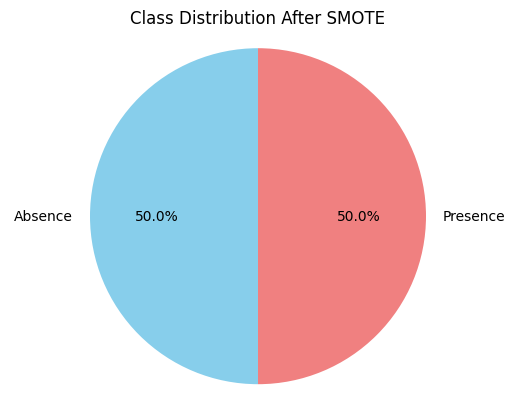

In [ ]:
plt.pie(y_resampled.value_counts(), labels=['Absence', 'Presence'], autopct='%1.1f%%',
        colors=['skyblue', 'lightcoral'], startangle=90)
plt.title('Class Distribution After SMOTE')
plt.axis('equal')
plt.show()

The data is now perfectly balanced.

AS Known that in medical dataset binery classification problem then the best choice is **Logistic Regression** because it's easy and preforms better and ill test too **SVM  and Random Forest** , becuse we have some non liner relations as we saw in data exploration


In [ ]:
X_train_resampled, X_test_resampled, y_train_resampled, y_test_resampled = train_test_split(X_resampled, y_resampled, test_size=0.20, random_state=42)

Splited data into training and testing sets (80% train, 20% test)

In [ ]:
scaler = StandardScaler()
X_train_resampled_scaled = scaler.fit_transform(X_train_resampled)
X_test_resampled_scaled = scaler.transform(X_test_resampled)

we used scaler to get sure every featuers contierbute equaly

In [ ]:
scaled_models = ['Logistic Regression', 'Support Vector Machine']

Let's declare our targated modls for this prediction as this as this is bassed on the graphs.

Loggistic Regression: Loggistic regression works well with binary classification problems where the features are not heavily correlated. and best chocies for medical .

Support Vectorr Machine (SVM): SVM can perform well in situations where the data is not linearly separable, and it uses kernel functions to handle non-linear relationships. The graphes like ST depression and Number of vesels fluro have more variations in distribution,

Random Forest: Random Forest can handle non-linearities in the data and is great at managing complex interactions between features. Based on graphs, features like ST depression and Number of vessels fluro seem to have complex distributions, and Random Forest can help by capturing the interaction between these features.

In [ ]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest Classifier': RandomForestClassifier(random_state=42),
    'Support Vector Machine': SVC(random_state=42),

}

**hyperparamter Tunining** for all modles

In [ ]:
param_grids = {
    'Logistic Regression': {
        'C': [0.01, 0.1, 1, 10, 100],
        'penalty': ['l1', 'l2'],
        'solver': ['liblinear', 'saga']
    },
    'Random Forest Classifier': {
        'n_estimators': [100, 200, 300],
        'max_depth': [10, 20, 30],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    },
    'Support Vector Machine': {
        'C': [0.1, 1, 10, 100],
        'kernel': ['linear', 'rbf', 'poly'],
        'gamma': ['scale', 'auto']
    },
    }

For Logistic Regression, I used diferent C values to controle regulerization, wich helps stop overfitting. The penalty and solver options are normal choices for regulerization and optimiztion.

For Random Forest, I changed n_estimators (number of trees) and max_depth to see how complex the model should be. The min_samples_split and min_samples_leaf control how the trees are built and avoid overfitting.

For SVM, I chose C values to balance accuracy and regulerization. The diferent kernel options change how the SVM makes decisions, and gamma values affect how far the influence of a single point goes.

**Models valdtion**

In [ ]:
def evaluate_classification_model(model, X_train, X_test, y_train, y_test, use_scaled=False):
    if use_scaled:
        model.fit(X_train_resampled_scaled, y_train)
        y_pred = model.predict(X_test_resampled_scaled)
    else:
        model.fit(X_train_resampled, y_train)
        y_pred = model.predict(X_test_resampled)

    accuracy = accuracy_score(y_test, y_pred)
    confusion = confusion_matrix(y_test, y_pred)
    classification = classification_report(y_test, y_pred, zero_division=0)

    return {
        'Accuracy': accuracy,
        'Confusion Matrix': confusion,
        'Classification Report': classification
    }

 i used this function to train classification models for the three types on both scaled and unscaled data. Then it checks how well they perform by calculating accuracy, a confusion matrix, and a classification report. It gives back these numbers to see how good the model is.

In [ ]:
best_models = {}
for model_name, model in models.items():
    if model_name in param_grids:
        print(f"Tuning hyperparameters for {model_name}...")
        grid_search = GridSearchCV(estimator=model, param_grid=param_grids[model_name], cv=5, n_jobs=-1, verbose=2)
        use_scaled = model_name in scaled_models
        grid_search.fit(X_train_resampled_scaled if use_scaled else X_train_resampled, y_train_resampled)
        best_models[model_name] = grid_search.best_estimator_
        print(f"Best parameters for {model_name}: {grid_search.best_params_}")
    else:
        ()

Tuning hyperparameters for Logistic Regression...
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters for Logistic Regression: {'C': 0.1, 'penalty': 'l2', 'solver': 'saga'}
Tuning hyperparameters for Random Forest Classifier...
Fitting 5 folds for each of 81 candidates, totalling 405 fits
Best parameters for Random Forest Classifier: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 300}
Tuning hyperparameters for Support Vector Machine...
Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best parameters for Support Vector Machine: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}


In [ ]:
resampled_results = {}
for model_name, model in best_models.items():
    print(f"Wait untill Evaluating {model_name} on resampled data...")
    use_scaled = model_name in scaled_models
    result = evaluate_classification_model(model, X_train_resampled, X_test_resampled, y_train_resampled, y_test_resampled, use_scaled=use_scaled)
    resampled_results[model_name] = result

Wait untill Evaluating Logistic Regression on resampled data...
Wait untill Evaluating Random Forest Classifier on resampled data...
Wait untill Evaluating Support Vector Machine on resampled data...


**Resluts **

In [ ]:
for model_name, metrics in resampled_results.items():
    print(f"\n--- {model_name} ---")
    print(f"Accuracy: {metrics['Accuracy']:.4f}")
    print("Confusion Matrix:")
    print(metrics['Confusion Matrix'])
    print("Classification Report:")
    print(metrics['Classification Report'])





--- Logistic Regression ---
Accuracy: 0.9167
Confusion Matrix:
[[28  3]
 [ 2 27]]
Classification Report:
              precision    recall  f1-score   support

     Absence       0.93      0.90      0.92        31
    Presence       0.90      0.93      0.92        29

    accuracy                           0.92        60
   macro avg       0.92      0.92      0.92        60
weighted avg       0.92      0.92      0.92        60


--- Random Forest Classifier ---
Accuracy: 0.8833
Confusion Matrix:
[[26  5]
 [ 2 27]]
Classification Report:
              precision    recall  f1-score   support

     Absence       0.93      0.84      0.88        31
    Presence       0.84      0.93      0.89        29

    accuracy                           0.88        60
   macro avg       0.89      0.88      0.88        60
weighted avg       0.89      0.88      0.88        60


--- Support Vector Machine ---
Accuracy: 0.8500
Confusion Matrix:
[[23  8]
 [ 1 28]]
Classification Report:
              precis

**Model Results Summary and selection:**
As we have seen three modles how is there accurcy but i chocesd **Logistic Regression** because it has the best acuraccy in addtion to this is the best model for its lower false negative count.False Negatives (FN) in a medical context, especially in cardiovascular disease (CVD) prediction, are a critical issue. Misclassifying a patient as not having heart disease when they actually do (False Negative) can lead to serious consequences, as those patients would not receive necessary treatment.

## **Accuracy : 91.67%**

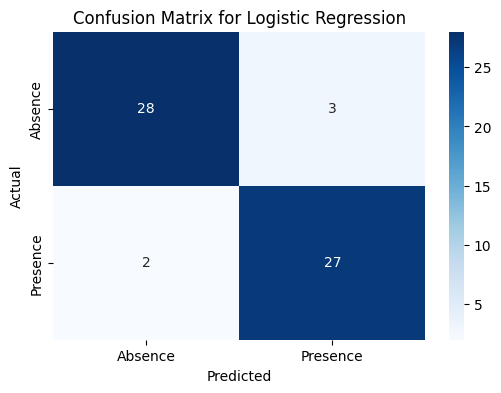

In [ ]:
confusion_matrix_lr = np.array([[28, 3],
                                 [2, 27]])
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix_lr,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['Absence', 'Presence'],
            yticklabels=['Absence', 'Presence'])
plt.title('Confusion Matrix for Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

***Important note and concerns :***



our model has preformed great but there are important note — **False Negatives (FN)** In a medcal context, especially in cardiovascular diseas (CVD) prediction, are a critical issue. Misclassifying a patient as not having heart desease when they actually do (False Negative) can lead to serious consequenses, as those patients would not receive nesesary treatment.

***Future Plans :***

our goal shouldbe reducing False Negatives (especially for predicting heart disease),with many ways but i think the best approach is likely Adjust the Decision Threshold and Class Weighting

# **Conclusion**

In this project, we worked to improve the prediction of the heart disease using machine learning. we started with preoplem understanding and explored our data then appliad what we have learned in our cousre. because Traditional methods often miss cases because heart disease can be complicated. By using machine learning, we aimed to solve this problem and help doctors make better decisions.

finaly, we got **91% accuracy**, but some people who had heart disease were incorrectly labeled as healthy (False Negatives). This made the models not very safe for medical use.

To fix this, we need to applay more featuer enginering and ml methods to get it negelacted and better accuracy

In the end, our model is good to for medical use **with caution** because it doen't makes sure all heart disease cases are caught. While it flags some healthy people.